<a href="https://colab.research.google.com/github/SNSIMANTO/ML-Research-Lab/blob/main/Employee_Attrition_Classification_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/drive/MyDrive/datasets/employee_attrition_classification_dataset.csv')
df.head()

Mounted at /content/drive


,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


In [ ]:
df.shape

(59598, 24)

In [ ]:
df.dtypes.value_counts()

,count
object,16
int64,8


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode target: Yes=1, No=0
df['Attrition'] = LabelEncoder().fit_transform(df['Attrition'])

# Keep only numeric columns for simplicity
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('Attrition')

X = df[num_cols]
y = df['Attrition']
X.columns.tolist()

['Employee ID',
 'Age',
 'Years at Company',
 'Monthly Income',
 'Number of Promotions',
 'Distance from Home',
 'Number of Dependents',
 'Company Tenure']

In [ ]:
# Feature 1: Annual income per year at company

df['Income_per_Year'] = df['Monthly Income'] / (df['Years at Company'] + 1)

# Feature 2: Loyalty ratio using age
# inverse of job-hopping tendency
df['Loyalty_Ratio'] = df['Years at Company'] / df['Age']

# Add new features to X
X['Income_per_Year'] = df['Income_per_Year']
X['Loyalty_Ratio'] = df['Loyalty_Ratio']

X[['Income_per_Year', 'Loyalty_Ratio']].head()

,Income_per_Year,Loyalty_Ratio
0,269.500000,0.612903
1,1106.800000,0.067797
2,741.727273,0.416667
3,498.625000,0.194444
4,114.785714,0.732143


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

features = [
    'Age',
    'Years at Company',
    'Monthly Income',
    'Number of Promotions',
    'Distance from Home',
    'Number of Dependents'
]

poly = PolynomialFeatures(degree=2, include_bias=False)

X_poly = poly.fit_transform(df[features])

poly_df = pd.DataFrame(
    X_poly,
    columns=poly.get_feature_names_out(features)
)

print(poly_df.head())

    Age  Years at Company  Monthly Income  Number of Promotions  \
0  31.0              19.0          5390.0                   2.0   
1  59.0               4.0          5534.0                   3.0   
2  24.0              10.0          8159.0                   0.0   
3  36.0               7.0          3989.0                   1.0   
4  56.0              41.0          4821.0                   0.0   

   Distance from Home  Number of Dependents   Age^2  Age Years at Company  \
0                22.0                   0.0   961.0                 589.0   
1                21.0                   3.0  3481.0                 236.0   
2                11.0                   3.0   576.0                 240.0   
3                27.0                   2.0  1296.0                 252.0   
4                71.0                   0.0  3136.0                2296.0   

   Age Monthly Income  Age Number of Promotions  ...  Monthly Income^2  \
0            167090.0                      62.0  ...        

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
import pandas as pd

# Select the numerical features you want
features = [
    'Age',
    'Years at Company',
    'Monthly Income',
    'Number of Promotions'
]

# Create interaction features only
poly = PolynomialFeatures(
    degree=2,
    include_bias=False,
    interaction_only=True
)

# Generate polynomial features
poly_features = poly.fit_transform(X[features])

# Get feature names
feature_names = poly.get_feature_names_out(features)

# Convert to DataFrame
poly_df = pd.DataFrame(poly_features, columns=feature_names)

# Display results
print(f"Shape: {poly_features.shape}")
print(f"Features: {list(feature_names)}\n")

print(poly_df.head())
print(poly_df.describe().round(2))

Shape: (59598, 10)
Features: ['Age', 'Years at Company', 'Monthly Income', 'Number of Promotions', 'Age Years at Company', 'Age Monthly Income', 'Age Number of Promotions', 'Years at Company Monthly Income', 'Years at Company Number of Promotions', 'Monthly Income Number of Promotions']

    Age  Years at Company  Monthly Income  Number of Promotions  \
0  31.0              19.0          5390.0                   2.0   
1  59.0               4.0          5534.0                   3.0   
2  24.0              10.0          8159.0                   0.0   
3  36.0               7.0          3989.0                   1.0   
4  56.0              41.0          4821.0                   0.0   

   Age Years at Company  Age Monthly Income  Age Number of Promotions  \
0                 589.0            167090.0                      62.0   
1                 236.0            326506.0                     177.0   
2                 240.0            195816.0                       0.0   
3               

Correlation with Attrition:

Distance from Home     -0.0956
Income_per_Year        -0.0530
Employee ID            -0.0027
Monthly Income          0.0114
Company Tenure          0.0303
Age                     0.0489
Loyalty_Ratio           0.0586
Years at Company        0.0649
Number of Dependents    0.0783
Number of Promotions    0.0806

Selected Features (|correlation| >= 0.05):

Distance from Home     -0.0956
Income_per_Year        -0.0530
Loyalty_Ratio           0.0586
Years at Company        0.0649
Number of Dependents    0.0783
Number of Promotions    0.0806


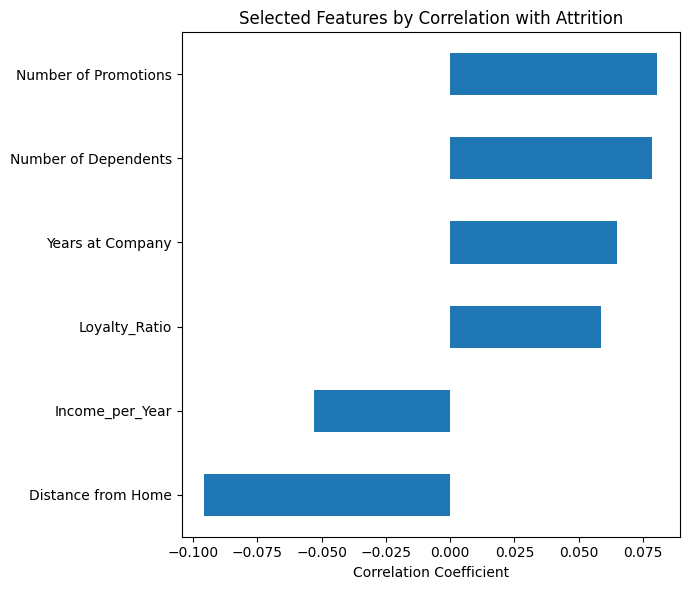

In [ ]:
import matplotlib.pyplot as plt

# Add engineered features from X to df
df['Income_per_Year'] = X['Income_per_Year']
df['Loyalty_Ratio'] = X['Loyalty_Ratio']

# Select numerical columns
corr = df[
    num_cols + ['Income_per_Year', 'Loyalty_Ratio', 'Attrition']
].corr(numeric_only=True)['Attrition'].drop('Attrition').sort_values()

# Print correlation values
print("Correlation with Attrition:\n")
print(corr.round(4).to_string())

# Filter features based on a threshold
# Changed threshold to 0.05 to include more features for visualization
threshold = 0.05
selected_features = corr[abs(corr) >= threshold]

print(f"\nSelected Features (|correlation| >= {threshold}):\n")

if not selected_features.empty:
    print(selected_features.round(4).to_string())

    # Plot
    selected_features.plot(
        kind='barh',
        figsize=(7,6),
        title='Selected Features by Correlation with Attrition'
    )
    plt.xlabel('Correlation Coefficient')
    plt.tight_layout()
    plt.show()
else:
    print("No features met the correlation threshold.")
    plt.figure(figsize=(7, 1))
    plt.text(0.5, 0.5, 'No features met the correlation threshold for plotting.', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)
    plt.axis('off')
    plt.show()